In [1]:
from scipy.optimize import curve_fit
from functools import wraps
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

import scipy
from scipy.stats import chi2

from coffea.util import load

import json
import numpy as np

In [2]:
class HepDataParser:
    """
    A class to parse HEPData JSON files and extract cross sections, errors, 
    and correlation matrices.
    """
    
    def __init__(self):
        pass
        
    @staticmethod
    def parse_cross_section(json_file_path):
        """
        Parses the main cross section JSON file to extract:
        - Bin edges
        - Central values (observed cross section)
        - Statistical errors
        - Systematic errors
        
        Returns:
            dict: Dictionary with 'bins', 'values', 'stat_errors', 'syst_errors'
        """
        with open(json_file_path, 'r') as f:
            data = json.load(f)
        
        result = {'bins': [], 'values': [], 'stat_errors': [], 'syst_errors': []}
        
        for entry in data['values']:
            # Extract bin edges
            bin_low = entry['x'][0]['low']
            bin_high = entry['x'][0]['high']
            result['bins'].append((float(bin_low), float(bin_high)))
            
            # Extract central value
            result['values'].append(float(entry['y'][0]['value']))
            
            # Extract errors
            for error in entry['y'][0]['errors']:
                if error.get('label') == 'stat':
                    result['stat_errors'].append(float(error['symerror']))
                elif error.get('label') == 'syst':
                    result['syst_errors'].append(float(error['symerror']))
        
        # Convert to numpy arrays
        for key in ['values', 'stat_errors', 'syst_errors']:
            result[key] = np.array(result[key])
            
        return result

    @staticmethod
    def parse_correlation_matrix(json_file_path, bins):
        """
        Parses the correlation matrix JSON file and constructs a proper matrix.
        
        Returns:
            np.ndarray: Correlation matrix of shape (n_bins, n_bins)
        """
        with open(json_file_path, 'r') as f:
            data = json.load(f)
        
        # Initialize correlation matrix
        n_bins = len(bins)
        corr_matrix = np.eye(n_bins)
        
        # Create a mapping from bin ranges to indices
        bin_to_index = {}
        for idx, (low, high) in enumerate(bins):
            bin_to_index[(low, high)] = idx
        
        # Fill the correlation matrix from the JSON data
        for entry in data['values']:
            # Get bin ranges from the x values
            x_bins = entry['x']
            bin1 = (float(x_bins[0]['low']), float(x_bins[0]['high']))
            bin2 = (float(x_bins[1]['low']), float(x_bins[1]['high']))
            
            # Get the correlation value and convert from percentage to fraction
            correlation_value = float(entry['y'][0]['value']) / 100.0
            
            # Find the indices for these bins
            if bin1 in bin_to_index and bin2 in bin_to_index:
                i = bin_to_index[bin1]
                j = bin_to_index[bin2]
                corr_matrix[i, j] = correlation_value
                corr_matrix[j, i] = correlation_value  # Symmetric matrix
        
        return corr_matrix
    
    @staticmethod
    def build_covariance_matrix(errors, correlation_matrix):
        """
        Builds covariance matrix from errors and correlation matrix.
        
        Args:
            errors (np.array): Array of errors (statistical or systematic)
            correlation_matrix (np.ndarray): Correlation matrix
            
        Returns:
            np.ndarray: Covariance matrix
        """
        n_bins = len(errors)
        covariance_matrix = np.zeros((n_bins, n_bins))
        
        for i in range(n_bins):
            for j in range(n_bins):
                covariance_matrix[i, j] = errors[i] * errors[j] * correlation_matrix[i, j]
        
        return covariance_matrix
    
    def get_inverse_covariance_matrix(self):
        pt_data = HepDataParser.parse_cross_section("json_files/diff_xsec_photon_pt.json")
        bins_pt = pt_data['bins']
        corr_stat_pt = HepDataParser.parse_correlation_matrix("json_files/stat_corr_pt.json", bins_pt)
        corr_syst_pt = HepDataParser.parse_correlation_matrix("json_files/syst_corr_pt.json", bins_pt)
        V_stat_pt = HepDataParser.build_covariance_matrix(pt_data['stat_errors'], corr_stat_pt)
        V_syst_pt = HepDataParser.build_covariance_matrix(pt_data['syst_errors'], corr_syst_pt)
        V_pt = V_stat_pt + V_syst_pt
        V_pt
        
        deltaphi_data = HepDataParser.parse_cross_section("json_files/deltaphi_ll.json")
        bins_deltaphi = deltaphi_data['bins']
        corr_stat_deltaphi = HepDataParser.parse_correlation_matrix("json_files/stat_corr_deltaphi.json", bins_deltaphi)
        corr_syst_deltaphi = HepDataParser.parse_correlation_matrix("json_files/syst_corr_deltaphi.json", bins_deltaphi)
        V_stat_deltaphi = HepDataParser.build_covariance_matrix(deltaphi_data['stat_errors'], corr_stat_deltaphi)
        V_syst_deltaphi = HepDataParser.build_covariance_matrix(deltaphi_data['syst_errors'], corr_syst_deltaphi)
        V_deltaphi = V_stat_deltaphi + V_syst_deltaphi
        V_deltaphi
        
        # Construct the full data vector and covariance matrix
        # Since cross-observable correlations are not published, we assume block diagonal
        self.y_data = np.concatenate([pt_data['values'], deltaphi_data['values']])
        self.V = scipy.linalg.block_diag(V_pt, V_deltaphi)
        
        # Precompute the inverse covariance matrix for chi2 calculation
        self.V_inv = np.linalg.inv(self.V)
        
        return self.V_inv

In [3]:
class ComputeLimit:
    def __init__(self, mass):
        self.output = load("output/output.coffea")
        self.mass = mass

    def compute_prefactor(self, width, coupling):
        return width/(coupling**2)

    def fit_decorator(func):
        @wraps(func)
        def wrapper(self, x, y, **kwarg):
            def fitting_function(x_data, a):
                return func(self, x_data, a)
            return curve_fit(fitting_function, x, y, **kwarg)
        return wrapper

    @fit_decorator
    def fit_prefactor(self, x, a):
        return a * x

    def compute_fiducial_acceptance(self, hist_name, mass):
        dataset = list(self.output["hists"]["total"][hist_name][mass].keys())[0]
        hist = list(self.output["hists"]["total"][hist_name][mass].values())[0]
        values = hist.values()
        xsec = self.output["metadata"][mass][dataset]["xsec"]*1000
        lumi = 138
        
        return values/(xsec * lumi)
    
    def compute_branching_ratios(self, g3g, g3gamma):
        """
        Calculates branching ratios B_g and B_gamma for given couplings.
        This uses the formulas from the paper and the prefactors you calculated.

        Args:
            g3g (float): Dipole coupling to gluons
            g3gamma (float): Dipole coupling to photons

        Returns:
            tuple: (B_g, B_gamma) branching ratios.
        """
        
        ggluon2 = []
        ggamma2 = []
        width_gamma = []
        width_gluon = []
        dataset = list(self.output["metadata"][self.mass].keys())[0]
        Gamma_wb = self.output["metadata"][self.mass][dataset]["width_T_wb"]
        for dataset, metadata in self.output["metadata"][self.mass].items():
            if metadata["gammaFlag"] == 1:
                ggluon2.append((metadata["gluonFlag"] * metadata["fvec3"])**2)
                width_gluon.append(metadata["width_T_tg"])
            if metadata["gluonFlag"] == 1:
                ggamma2.append((metadata["gammaFlag"] * metadata["fvec3"])**2)
                width_gamma.append(metadata["width_T_ta"])
        
        # Calculate prefactor
        xt = (173.0 / self.mass) ** 2  # xt = (mt / mT)^2
        width_factor = ((self.mass ** 3) / (1000 ** 2)) * (1 - xt) ** 3  # Lambda = 1000 GeV (3 TeV)
        gamma_width_factor = width_factor * np.array(ggamma2)
        gluon_width_factor = width_factor * np.array(ggluon2)
        
        fit_tg_results = self.fit_prefactor(gluon_width_factor, width_gluon)
        gluon_prefactor = fit_tg_results[0][0]
        # print(f"Error on width T -> tg: {fit_tg_results[1]}")
        fit_ta_results = self.fit_prefactor(gamma_width_factor, width_gamma)
        gamma_prefactor = fit_ta_results[0][0]
        # print(f"Error on width T -> ta: {fit_ta_results[1]}")

        Gamma_tg = gluon_prefactor * width_factor * (g3g ** 2)
        Gamma_tgamma = gamma_prefactor * width_factor * (g3gamma ** 2)
        
        # Assuming these are the only decay channels
        Gamma_total = Gamma_tg + Gamma_tgamma + Gamma_wb

        # Calculate Branching Ratios
        B_g = Gamma_tg / Gamma_total
        B_gamma = Gamma_tgamma / Gamma_total

        return B_g, B_gamma
        
    def get_signal_vector(self, g3g, g3gamma):
        """
        Constructs the signal prediction vector s for given couplings.
        (Eq. 7 in the paper)

        Args:
            g3g (float): Dipole coupling to gluons
            g3gamma (float): Dipole coupling to photons

        Returns:
            np.array: Signal vector s (concatenated pT_gamma and DeltaPhi_ll bins)
        """
        # 1. Get the branching ratios
        B_g, B_gamma = self.compute_branching_ratios(g3g, g3gamma)
        f1gamma = 2 * B_gamma * B_g  # Probability for 1 gamma in TTbar event

        # 2. Get the normalized template shapes for a reference coupling (1, 1)
        # The shape is assumed to be independent of the coupling strength, only the normalisation changes.
        # This is a key assumption from the paper (afid is precomputed from MC).
        fiducial_acceptance_pt = self.compute_fiducial_acceptance("diff_xsec_photon_pt", self.mass)
        fiducial_acceptance_deltaphi = self.compute_fiducial_acceptance("deltaphi_ll", self.mass)

        # 3. Calculate the predicted fiducial cross section in each bin
        # sigma_X,i_fid = sigma_pair * f1gamma * a_X,i_fid
        ggluon = []
        xsec_TT = []
        for dataset, metadata in self.output["metadata"][self.mass].items():
            if metadata["gammaFlag"] == 1:
                ggluon.append(metadata["gluonFlag"] * metadata["fvec3"])
                xsec_TT.append(metadata["xsec_TT"])
        if len(ggluon)<=2:
            ggluon = ggluon + ggluon
            xsec_TT = xsec_TT + xsec_TT        
        
        # sigma_TT = (a + b * g3g ** 2) ** 2
        xsec_TT_prefactors = curve_fit(lambda x, a, b:  a ** 2 + 2 * a * b * x ** 2 + b ** 2 * x ** 4, np.array(ggluon), xsec_TT)
        # print(f"Cross section fit results: {xsec_TT_prefactors}")
        a = xsec_TT_prefactors[0][0]
        b = xsec_TT_prefactors[0][1]
        sigma_TT = a ** 2 + 2 * a * b * g3g ** 2 + b ** 2 * g3g ** 4
        
        sigma_TT_fb = sigma_TT *1000
        s_pT = sigma_TT_fb * f1gamma * fiducial_acceptance_pt
        s_dphi = sigma_TT_fb * f1gamma * fiducial_acceptance_deltaphi

        # 4. Concatenate the vectors to form the full signal prediction
        s_total = np.concatenate([s_pT, s_dphi])
        return s_total
        
    def chi_square(self, g3g, g3gamma):
        """
        Calculates the chi2 test statistic for given couplings.
        (Eq. 8 in the paper: s^T V^{-1} s)

        Args:
            g3g (float): Dipole coupling to gluons
            g3gamma (float): Dipole coupling to photons

        Returns:
            float: The chi2 value.
        """
        s_vec = self.get_signal_vector(g3g, g3gamma)
        # The paper assumes the SM is the null hypothesis (data = 0),
        # and s is the NP signal prediction.
        V_inv = HepDataParser().get_inverse_covariance_matrix()
        chi2_val = s_vec @ V_inv @ s_vec
        return chi2_val
    
#     def plot(func):
#         @wraps(func)
#         def wrapper(self, chi2_critical=chi2.ppf(0.95, df=11), **kwargs):
#             X, Y, Z = func(self, **kwargs)
#             plt.figure(figsize=(8, 6))
#             plt.contourf(X, Y, Z, levels=[chi2_critical, Z.max()], colors=['lightcoral'])
#             plt.contour(X, Y, Z, levels=[chi2_critical], colors='black', linewidths=2)
            
#             legend_elements = [
#                 Patch(facecolor='lightcoral', alpha=0.7, label=f'$\chi^2 > {chi2_critical:.2f}$'),
#                 Line2D([0], [0], color='black', linewidth=2, label=f'$\chi^2 = {chi2_critical:.2f}$ (95% CL)')
#             ]
#             plt.xlabel('$g_{3g} (\mathrm{TeV^{-1}})$')
#             plt.ylabel('$g_{3\\gamma} (\mathrm{TeV^{-1}})$')
#             plt.title(f'95% CL Exclusion Contour for mT = {self.mass} GeV')
#             plt.grid()
#             plt.legend(handles=legend_elements)
#             plt.savefig(f"plots/limit_landa{self.mass}.png")
#             plt.savefig(f'plots/limit_landa{self.mass}.svg', format='svg', dpi=1200)
#             plt.show()
#         return wrapper
    def plot(func):
        @wraps(func)
        def wrapper(self, **kwargs):
            X, Y, Z = func(self, **kwargs)

            # Calculate critical values for 68% and 95% CL (for 2 parameters)
            chi2_68 = chi2.ppf(0.68, df=11)  
            chi2_95 = chi2.ppf(0.95, df=11)  

            plt.figure(figsize=(8, 6))

            # Fill regions for different confidence levels
            plt.contourf(X, Y, Z, levels=[chi2_95, Z.max()], colors=['lightcoral'], alpha=0.7)
            plt.contourf(X, Y, Z, levels=[chi2_68, chi2_95], colors=['gold'], alpha=0.7)

            # Draw contour lines
            contour_95 = plt.contour(X, Y, Z, levels=[chi2_95], colors='red', linewidths=2, linestyles='-')
            contour_68 = plt.contour(X, Y, Z, levels=[chi2_68], colors='orange', linewidths=2, linestyles='-')

            legend_elements = [
                Patch(facecolor='gold', alpha=0.7, label='68% CL region'),
                Patch(facecolor='lightcoral', alpha=0.7, label='95% CL region'),
                Line2D([0], [0], color='orange', linewidth=2, label='68% CL contour'),
                Line2D([0], [0], color='red', linewidth=2, label='95% CL contour')
            ]

            plt.xlabel('$g_{3g} (\mathrm{TeV^{-1}})$')
            plt.ylabel('$g_{3\\gamma} (\mathrm{TeV^{-1}})$')
            plt.title(f'Exclusion Contours for mT = {self.mass} GeV')
            plt.grid()
            plt.legend(handles=legend_elements)
            plt.savefig(f"plots/limit_landa{self.mass}.png")
            # plt.savefig(f'plots/limit_landa{self.mass}.svg', format='svg', dpi=1200)
            plt.show()
        return wrapper
            
    
    # @plot
    def find_contour(self, g3g_range=(-2.5, 2.5), g3gamma_range=(-2.5, 2.5), n_points=250):
        """
        Scans the (g3g, g3gamma) parameter space and finds the 95% CL contour.

        Args:
            g3g_range (tuple): (min, max) range for g3g scan.
            g3gamma_range (tuple): (min, max) range for g3gamma scan.
            n_points (int): Number of points along each axis.

        Returns:
            tuple: (X, Y, Z) meshgrid arrays and the chi2 values on the grid.
        """
        g3g_vals = np.linspace(g3g_range[0], g3g_range[1], n_points)
        g3gamma_vals = np.linspace(g3gamma_range[0], g3gamma_range[1], n_points)
        G3g, G3gamma = np.meshgrid(g3g_vals, g3gamma_vals)
        Chi2Grid = np.zeros_like(G3g)

        # Calculate chi2 for each point in the grid
        for i, g3g_val in enumerate(g3g_vals):
            for j, g3gamma_val in enumerate(g3gamma_vals):
                # Avoid (0, 0) to prevent division by zero in BR calculation
                if g3g_val == 0 and g3gamma_val == 0:
                    Chi2Grid[j, i] = 0
                else:
                    Chi2Grid[j, i] = self.chi_square(g3g_val, g3gamma_val)

        return G3g, G3gamma, Chi2Grid
    
#     def plot_branching_fraction_contour(self, chi2_critical=chi2.ppf(0.95, df=11)):
#         """
#         Convert the coupling contour to branching fraction space
#         """
#         # Get the coupling contour points
#         g3g_vals = np.linspace(-3, 3, 150)
#         g3gamma_vals = np.linspace(-3, 3, 150)
#         G3g, G3gamma = np.meshgrid(g3g_vals, g3gamma_vals)
#         Chi2Grid = np.zeros_like(G3g)

#         B_g_grid = np.zeros_like(G3g)
#         B_gamma_grid = np.zeros_like(G3g)

#         # Calculate chi2 and branching fractions for each point
#         for i, g3g_val in enumerate(g3g_vals):
#             for j, g3gamma_val in enumerate(g3gamma_vals):
#                 if g3g_val == 0 and g3gamma_val == 0:
#                     Chi2Grid[j, i] = 0
#                     B_g_grid[j, i] = 0
#                     B_gamma_grid[j, i] = 0
#                 else:
#                     Chi2Grid[j, i] = self.chi_square(g3g_val, g3gamma_val)
#                     B_g, B_gamma = self.compute_branching_ratios(g3g_val, g3gamma_val)
#                     B_g_grid[j, i] = B_g
#                     B_gamma_grid[j, i] = B_gamma

#         # Plot in branching fraction space
#         plt.figure(figsize=(8, 6))
#         contour = plt.contour(B_gamma_grid, B_g_grid, Chi2Grid, levels=[chi2_critical], colors='black', linewidths=2)
#         plt.contourf(B_gamma_grid, B_g_grid, Chi2Grid, levels=[chi2_critical, Chi2Grid.max()], 
#                      colors=['lightcoral'], alpha=0.7)

#         plt.xlabel('$\mathcal{B}_{\gamma} = BR(T \\to t\gamma)$')
#         plt.ylabel('$\mathcal{B}_{g} = BR(T \\to tg)$')
#         plt.title(f'95% CL Exclusion Contour in Branching Fraction Space (mT = {self.mass} GeV)')
#         plt.grid(True)
#         plt.xlim(0, 1)
#         plt.ylim(0, 1)

#         # Add diagonal line for B_gamma + B_g <= 1 constraint
#         x_line = np.linspace(0, 1, 100)
#         y_line = 1 - x_line
#         plt.plot(x_line, y_line, 'b--', alpha=0.5, label='$\mathcal{B}_{\gamma} + \mathcal{B}_{g} \leq 1$')

#         legend_elements = [
#             Patch(facecolor='lightcoral', alpha=0.7, label='Excluded region'),
#             Line2D([0], [0], color='black', linewidth=2, label='95% CL contour'),
#             Line2D([0], [0], color='blue', linestyle='--', label='$\mathcal{B}_{\gamma} + \mathcal{B}_{g} \leq 1$')
#         ]
#         plt.legend(handles=legend_elements)

#         # plt.savefig("plots/limit_branching_fractions.png")
#         # plt.savefig('plots/limit_branching_fractions.svg', format='svg', dpi=1200)
#         plt.show()

#         return B_gamma_grid, B_g_grid, Chi2Grid

        

In [4]:
class ComputeLimitBR:
    xsec_TT = 1
    def __init__(self, mass):
        self.output = load("output/output.coffea")
        self.mass = mass

    def compute_fiducial_acceptance(self, hist_name, mass):
        dataset = list(self.output["hists"]["total"][hist_name][mass].keys())[0]
        hist = list(self.output["hists"]["total"][hist_name][mass].values())[0]
        values = hist.values()
        xsec = self.output["metadata"][mass][dataset]["xsec"]*1000
        lumi = 138
        
        return values/(xsec * lumi)
    
    def get_signal_vector(self, br_g, br_gamma):
        """
        Constructs the signal prediction vector s for given couplings.
        (Eq. 7 in the paper)

        Args:
            g3g (float): Dipole coupling to gluons
            g3gamma (float): Dipole coupling to photons

        Returns:
            np.array: Signal vector s (concatenated pT_gamma and DeltaPhi_ll bins)
        """
        # 1. Get the branching ratios
        # B_g, B_gamma = self.compute_branching_ratios(g3g, g3gamma)
        # f1gamma = 2 * B_gamma * B_g  # Probability for 1 gamma in TTbar event

        # 2. Get the normalized template shapes for a reference coupling (1, 1)
        # The shape is assumed to be independent of the coupling strength, only the normalisation changes.
        # This is a key assumption from the paper (afid is precomputed from MC).
        fiducial_acceptance_pt = self.compute_fiducial_acceptance("diff_xsec_photon_pt", self.mass)
        fiducial_acceptance_deltaphi = self.compute_fiducial_acceptance("deltaphi_ll", self.mass)

        # 3. Calculate the predicted fiducial cross section in each bin
        # sigma_X,i_fid = sigma_pair * f1gamma * a_X,i_fid
        b_g = []
        xsec_TT = []
        for dataset, metadata in self.output["metadata"][self.mass].items():
            if metadata["gammaFlag"] == 1:
                br = metadata["width_T_tg"]/(metadata["width_T_tg"]+metadata["width_T_ta"]+metadata["width_T_wb"])
                b_g.append(br)
                xsec_TT.append(metadata["xsec_TT"])
        
        if len(b_g)<=2:
            b_g = b_g + b_g
            xsec_TT = xsec_TT + xsec_TT
        
        xsec_TT_prefactors = curve_fit(lambda x, a, b: (a + b * x)**2, np.array(b_g), xsec_TT)
        # print(xsec_TT_prefactors)
        sigma_TT = (xsec_TT_prefactors[0][0] + xsec_TT_prefactors[0][1] * br_g) ** 2
        
        sigma_TT_fb = sigma_TT * 1000
        s_pT = sigma_TT_fb * 2 * br_g * br_gamma * fiducial_acceptance_pt
        s_dphi = sigma_TT_fb * 2 * br_g * br_gamma * fiducial_acceptance_deltaphi

        # 4. Concatenate the vectors to form the full signal prediction
        s_total = np.concatenate([s_pT, s_dphi])
        return s_total
        
    def chi_square(self, br_g, br_gamma):
        """
        Calculates the chi2 test statistic for given couplings.
        (Eq. 8 in the paper: s^T V^{-1} s)

        Args:
            g3g (float): Dipole coupling to gluons
            g3gamma (float): Dipole coupling to photons

        Returns:
            float: The chi2 value.
        """
        s_vec = self.get_signal_vector(br_g, br_gamma)
        # The paper assumes the SM is the null hypothesis (data = 0),
        # and s is the NP signal prediction.
        V_inv = HepDataParser().get_inverse_covariance_matrix()
        chi2_val = s_vec @ V_inv @ s_vec
        return chi2_val
    
#     def plot(func):
#         @wraps(func)
#         def wrapper(self, chi2_critical=chi2.ppf(0.95, df=11), **kwargs):
#             X, Y, Z = func(self, **kwargs)
#             plt.figure(figsize=(8, 6))
#             plt.contourf(X, Y, Z, levels=[chi2_critical, Z.max()], colors=['lightcoral'])
#             plt.contour(X, Y, Z, levels=[chi2_critical], colors='black', linewidths=2)
            
#             legend_elements = [
#                 Patch(facecolor='lightcoral', alpha=0.7, label=f'$\chi^2 > {chi2_critical:.2f}$'),
#                 Line2D([0], [0], color='black', linewidth=2, label=f'$\chi^2 = {chi2_critical:.2f}$ (95% CL)')
#             ]
#             plt.xlabel('$\mathcal{B}_{g} = BR(T \\to tg)$')
#             plt.ylabel('$\mathcal{B}_{\gamma} = BR(T \\to t\gamma)$')
#             plt.title(f'95% CL Exclusion Contour in Branching Fraction Space (mT = {self.mass} GeV)')
#             plt.grid()
            
#             # Add diagonal line for B_gamma + B_g <= 1 constraint
#             x_line = np.linspace(0, 1, 100)
#             y_line = 1 - x_line
#             plt.plot(x_line, y_line, 'b--', alpha=0.5, label='$\mathcal{B}_{\gamma} + \mathcal{B}_{g} \leq 1$')
            
#             # plt.fill_between(x_line, y_line, 1, color='white', alpha=1, label='Unphysical region')
            
#             legend_elements = [
#                 Patch(facecolor='lightcoral', alpha=0.7, label='Excluded region'),
#                 Line2D([0], [0], color='black', linewidth=2, label='95% CL contour'),
#                 Line2D([0], [0], color='blue', linestyle='--', label='$\mathcal{B}_{\gamma} + \mathcal{B}_{g} \leq 1$')
#             ]
            
#             plt.legend(handles=legend_elements)
#             plt.savefig(f"plots/limit_br_{self.mass}.png")
#             plt.savefig(f'plots/limit_br_{self.mass}.svg', format='svg', dpi=1200)
#             plt.show()
#         return wrapper

    def plot(func):
        @wraps(func)
        def wrapper(self, **kwargs):
            X, Y, Z = func(self, **kwargs)

            # Calculate critical values for 68% and 95% CL (for 2 parameters)
            chi2_68 = chi2.ppf(0.68, df=11)
            chi2_95 = chi2.ppf(0.95, df=11)

            plt.figure(figsize=(8, 6))

            # Fill regions for different confidence levels
            plt.contourf(X, Y, Z, levels=[chi2_95, Z.max()], colors=['lightcoral'], alpha=0.7)
            plt.contourf(X, Y, Z, levels=[chi2_68, chi2_95], colors=['gold'], alpha=0.7)

            # Draw contour lines
            contour_95 = plt.contour(X, Y, Z, levels=[chi2_95], colors='red', linewidths=2, linestyles='-')
            contour_68 = plt.contour(X, Y, Z, levels=[chi2_68], colors='orange', linewidths=2, linestyles='-')

            # Add diagonal line for B_gamma + B_g <= 1 constraint
            x_line = np.linspace(0, 1, 100)
            y_line = 1 - x_line
            plt.plot(x_line, y_line, 'b--', alpha=0.5, label='$\mathcal{B}_{\gamma} + \mathcal{B}_{g} \leq 1$')

            legend_elements = [
                Patch(facecolor='gold', alpha=0.7, label='68% CL region'),
                Patch(facecolor='lightcoral', alpha=0.7, label='95% CL region'),
                Line2D([0], [0], color='orange', linewidth=2, label='68% CL contour'),
                Line2D([0], [0], color='red', linewidth=2, label='95% CL contour'),
                # Line2D([0], [0], color='blue', linestyle='--', label='$\mathcal{B}_{\gamma} + \mathcal{B}_{g} \leq 1$')
            ]

            plt.xlabel('$\mathcal{B}_{g} = BR(T \\to tg)$')
            plt.ylabel('$\mathcal{B}_{\gamma} = BR(T \\to t\gamma)$')
            plt.title(f'Exclusion Contours in Branching Fraction Space (mT = {self.mass} GeV)')
            plt.grid()
            plt.xlim(0, 1)
            plt.ylim(0, 1)
            plt.legend(handles=legend_elements)
            plt.savefig(f"plots/limit_br_{self.mass}.png")
            # plt.savefig(f'plots/limit_br_{self.mass}.svg', format='svg', dpi=1200)
            plt.show()
        return wrapper

    
    # @plot
    def find_contour(self, br_g_range=(0, 1), br_gamma_range=(0, 1), n_points=150):
        """
        Scans the (g3g, g3gamma) parameter space and finds the 95% CL contour.

        Args:
            g3g_range (tuple): (min, max) range for g3g scan.
            g3gamma_range (tuple): (min, max) range for g3gamma scan.
            n_points (int): Number of points along each axis.

        Returns:
            tuple: (X, Y, Z) meshgrid arrays and the chi2 values on the grid.
        """
        br_g_vals = np.linspace(br_g_range[0], br_g_range[1], n_points)
        br_gamma_vals = np.linspace(br_gamma_range[0], br_gamma_range[1], n_points)
        Br_g, Br_gamma = np.meshgrid(br_g_vals, br_gamma_vals)
        Chi2Grid = np.zeros_like(Br_g)

        # Calculate chi2 for each point in the grid
        for i, br_g_val in enumerate(br_g_vals):
            for j, br_gamma_val in enumerate(br_gamma_vals):
                # Avoid (0, 0) to prevent division by zero in BR calculation
                if br_g_val == 0 and br_gamma_val == 0:
                    Chi2Grid[j, i] = 0
                elif br_g_val + br_gamma_val>=1:
                    Chi2Grid[j, i] = np.inf
                else:
                    Chi2Grid[j, i] = self.chi_square(br_g_val, br_gamma_val)

        return Br_g, Br_gamma, Chi2Grid
    
    

In [5]:
for mass in [500, 750, 1000, 1250, 1500, 1750, 2000]:
    compute_limit = ComputeLimit(mass)
    ggluon2 = []
    ggamma2 = []
    width_gamma = []
    width_gluon = []
    width_wb = []
    xsec_TT = []    
    for dataset, metadata in compute_limit.output["metadata"][compute_limit.mass].items():
        if metadata["gammaFlag"] == 1:
            ggluon2.append((metadata["gluonFlag"] * metadata["fvec3"])**2)
            xsec_TT.append(metadata["xsec_TT"])
            width_gluon.append(metadata["width_T_tg"])
        if metadata["gluonFlag"] == 1:
            ggamma2.append((metadata["gammaFlag"] * metadata["fvec3"])**2)
            width_gamma.append(metadata["width_T_ta"])
    print("mass:", mass)
    print("gluonFlag:", ggluon2)
    print("width_gluon:", width_gluon)
    print("Fit Parameters:", compute_limit.fit_prefactor(np.array(ggluon2), width_gluon))
    print("")
    
    print("gammaFlag:", ggamma2)
    print("width_gamma:", width_gamma)
    print("Fit Parameters:", compute_limit.fit_prefactor(np.array(ggamma2), width_gamma))
    print("")
    
    print("xsec_TT:", xsec_TT)
    
    if len(ggluon2)<=2:
        ggluon2 = ggluon2 + ggluon2
        xsec_TT = xsec_TT + xsec_TT 
    
    xsec_TT_prefactors = curve_fit(lambda x, a, b:  (a + b * x) ** 2, np.array(ggluon2), xsec_TT)
    print("Fit Parameters:", xsec_TT_prefactors)
    
    print("####################################################################")

mass: 500
gluonFlag: [1.0, 1.0, 0.25, 0.25]
width_gluon: [18.179343, 18.179343, 4.544835, 4.544835]
Fit Parameters: (array([18.17934282]), array([[1.66089967e-13]]))

gammaFlag: [1.0, 0.25, 0.25, 1.0]
width_gamma: [13.634507, 3.408626, 3.408626, 13.634507]
Fit Parameters: (array([13.63450682]), array([[1.66089965e-13]]))

xsec_TT: [19.37, 19.32, 4.807, 4.8]
Fit Parameters: (array([1.45615342, 2.9421417 ]), array([[ 2.99383366e-05, -3.13108915e-05],
       [-3.13108915e-05,  3.68011126e-05]]))
####################################################################
mass: 750
gluonFlag: [1.0, 0.25]
width_gluon: [76.129215, 19.032303]
Fit Parameters: (array([76.12921482]), array([[4.98269893e-13]]))

gammaFlag: [0.25, 1.0]
width_gamma: [14.274227, 57.096911]
Fit Parameters: (array([57.09691082]), array([[4.98269894e-13]]))

xsec_TT: [4.939, 0.8451]
Fit Parameters: (array([0.48492891, 1.7374572 ]), array([[ 3.27581688e-33, -3.37980164e-33],
       [-3.37980164e-33,  3.79574102e-33]]))
########

CALCULATING DIAGONAL BRANCHING FRACTION LIMITS
FOR YOUR SPECIFIC ANALYSIS

Method 1: Root Finding
--------------------------------------------------

DIAGONAL BRANCHING FRACTION LIMITS AT 95% CL
Condition: Br(T→t+γ) = Br(T→t+g)

          Your Results
--------------------------------------------------
  mT= 500 GeV :  Bgamma = Bg < 0.279291
  mT= 750 GeV :  Bgamma = Bg < 0.443380
  mT=1000 GeV :  Bgamma = Bg < 0.500000 (full range allowed)
  mT=1250 GeV :  Bgamma = Bg < 0.500000 (full range allowed)
  mT=1500 GeV :  Bgamma = Bg < 0.500000 (full range allowed)
  mT=1750 GeV :  Bgamma = Bg < 0.500000 (full range allowed)
  mT=2000 GeV :  Bgamma = Bg < 0.500000 (full range allowed)

Method 2: Scanning Method
--------------------------------------------------

DIAGONAL BRANCHING FRACTION LIMITS (Scan Method)
  mT= 500 GeV :  Bgamma = Bg < 0.279291
  mT= 750 GeV :  Bgamma = Bg < 0.443380
  mT=1000 GeV :  Bgamma = Bg < 0.500000
  mT=1250 GeV :  Bgamma = Bg < 0.500000
  mT=1500 GeV :  Bgamma 

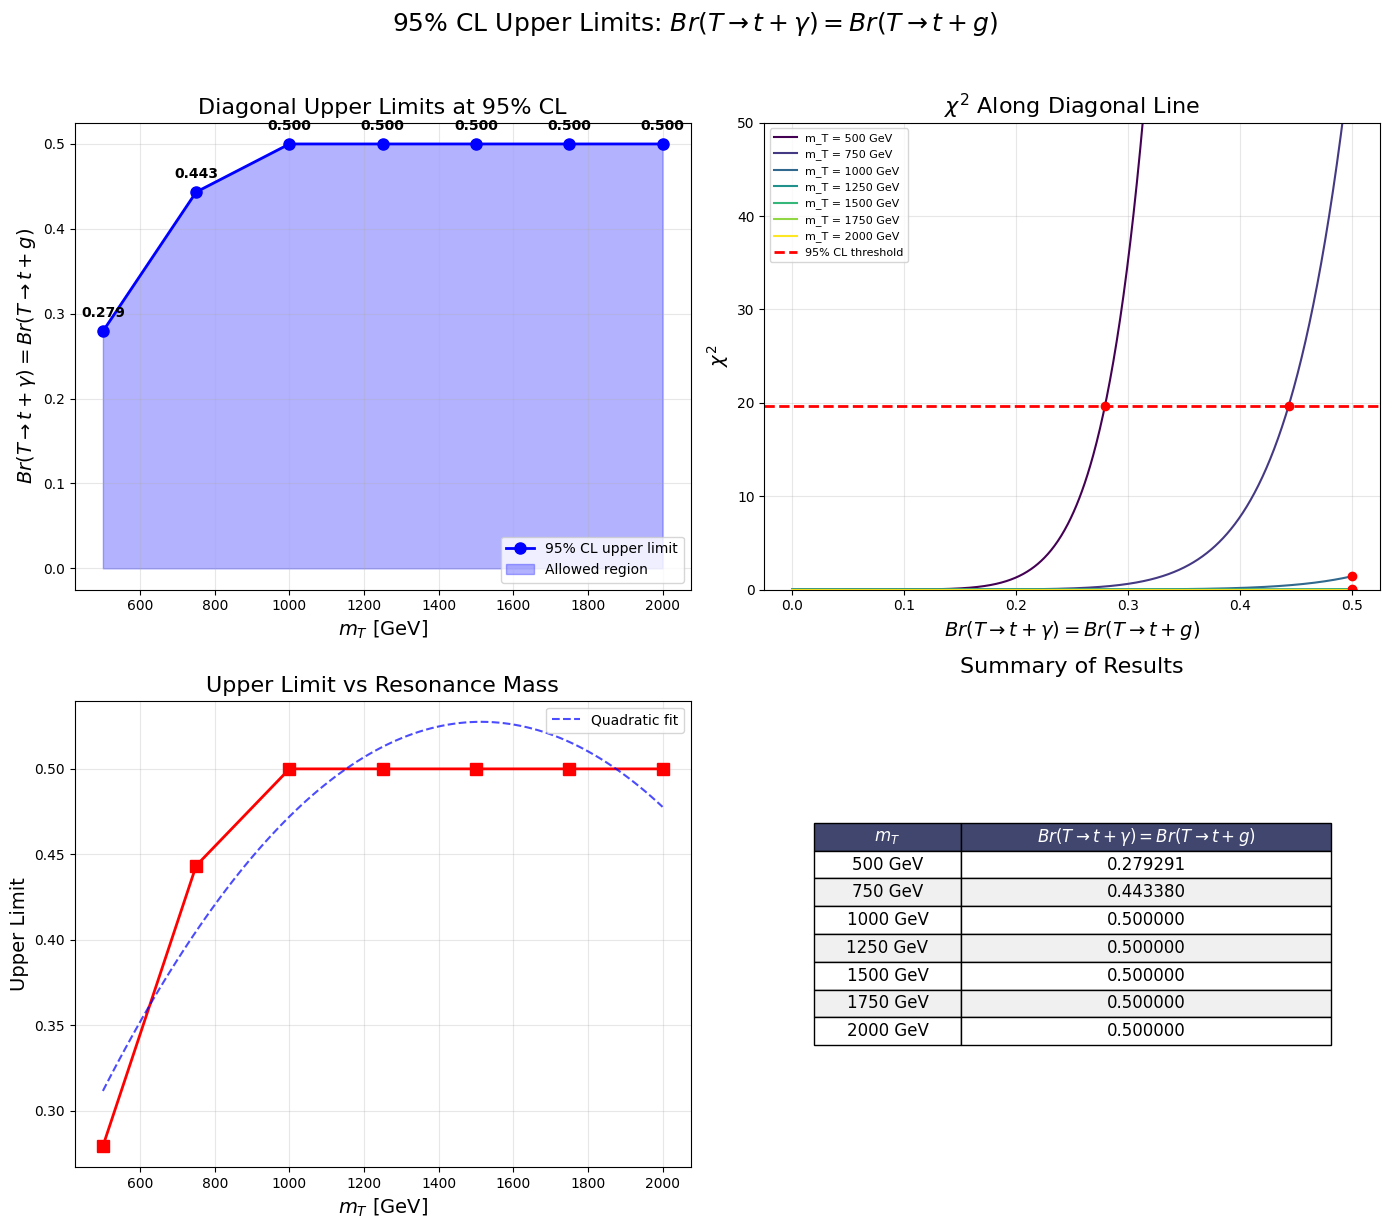


SUMMARY - Your Results:
These are the actual values for YOUR analysis:
  mT= 500 GeV :  Bgamma = Bg < 0.279291
  mT= 750 GeV :  Bgamma = Bg < 0.443380
  mT=1000 GeV :  Bgamma = Bg < 0.500000
  mT=1250 GeV :  Bgamma = Bg < 0.500000
  mT=1500 GeV :  Bgamma = Bg < 0.500000
  mT=1750 GeV :  Bgamma = Bg < 0.500000
  mT=2000 GeV :  Bgamma = Bg < 0.500000


In [6]:
import numpy as np
from scipy.optimize import brentq
from scipy.stats import chi2
import matplotlib.pyplot as plt

def calculate_diagonal_br_limits(mass_points, compute_limit_class):
    """
    Calculate diagonal branching fraction limits for all mass points.
    
    Args:
        mass_points: List of mass points [500, 750, 1000, 1250, 1500, 1750, 2000]
        compute_limit_class: Your ComputeLimit class
        
    Returns:
        Dictionary with mass points as keys and limits as values
    """
    # 95% CL threshold with 11 degrees of freedom
    chi2_threshold = chi2.ppf(0.95, df=11)
    
    results = {}
    
    print("\n" + "="*70)
    print("DIAGONAL BRANCHING FRACTION LIMITS AT 95% CL")
    print("Condition: Br(T→t+γ) = Br(T→t+g)")
    print("="*70)
    print("\n" + " "*10 + "Your Results")
    print("-"*50)
    
    for mass in mass_points:
        # Create compute limit instance for this mass
        compute_limit = compute_limit_class(mass)
        
        # Define function to find root: chi2(br, br) - chi2_threshold = 0
        def chi2_diff(br):
            if br < 0 or br > 0.5:  # Physical constraint: 2*br <= 1
                return np.inf
            return compute_limit.chi_square(br, br) - chi2_threshold
        
        # Check if at br=0 we're already above threshold (unlikely)
        if chi2_diff(1e-6) > 0:
            results[mass] = 0.0
            print(f"  mT={mass:4d} GeV :  Bgamma = Bg < 0.000000 (no allowed region)")
            continue
        
        # Find the upper limit using root finding
        try:
            # Search in range [0, 0.5]
            upper_limit = brentq(chi2_diff, 0, 0.5, xtol=1e-8, rtol=1e-8)
            results[mass] = upper_limit
            print(f"  mT={mass:4d} GeV :  Bgamma = Bg < {upper_limit:.6f}")
        except ValueError:
            # If no root found, check if all points are below threshold
            if compute_limit.chi_square(0.5, 0.5) < chi2_threshold:
                results[mass] = 0.5
                print(f"  mT={mass:4d} GeV :  Bgamma = Bg < 0.500000 (full range allowed)")
            else:
                results[mass] = None
                print(f"  mT={mass:4d} GeV :  No solution found")
    
    return results


def calculate_with_scan_method(mass_points, compute_limit_class, n_points=1000):
    """
    Alternative method using scanning for better visualization.
    
    Args:
        mass_points: List of mass points
        compute_limit_class: Your ComputeLimit class
        n_points: Number of points to scan
        
    Returns:
        Dictionary with results and also returns scan data for plotting
    """
    chi2_threshold = chi2.ppf(0.95, df=11)
    results = {}
    scan_data = {}
    
    print("\n" + "="*70)
    print("DIAGONAL BRANCHING FRACTION LIMITS (Scan Method)")
    print("="*70)
    
    for mass in mass_points:
        compute_limit = compute_limit_class(mass)
        
        # Scan along diagonal
        br_vals = np.linspace(0, 0.5, n_points)
        chi2_vals = np.array([compute_limit.chi_square(br, br) for br in br_vals])
        
        # Store scan data
        scan_data[mass] = {'br': br_vals, 'chi2': chi2_vals}
        
        # Find where chi2 crosses threshold
        above_threshold = np.where(chi2_vals > chi2_threshold)[0]
        
        if len(above_threshold) == 0:
            # All points below threshold
            results[mass] = 0.5
            print(f"  mT={mass:4d} GeV :  Bgamma = Bg < 0.500000")
        else:
            # Find first crossing
            first_cross = above_threshold[0]
            if first_cross == 0:
                results[mass] = 0.0
                print(f"  mT={mass:4d} GeV :  Bgamma = Bg < 0.000000")
            else:
                # Interpolate
                br1, br2 = br_vals[first_cross-1], br_vals[first_cross]
                chi2_1, chi2_2 = chi2_vals[first_cross-1], chi2_vals[first_cross]
                
                br_limit = br1 + (br2 - br1) * (chi2_threshold - chi2_1) / (chi2_2 - chi2_1)
                results[mass] = br_limit
                print(f"  mT={mass:4d} GeV :  Bgamma = Bg < {br_limit:.6f}")
    
    return results, scan_data


def plot_diagonal_results(results, scan_data=None):
    """
    Plot the diagonal branching fraction limits.
    
    Args:
        results: Dictionary with mass points and limits
        scan_data: Optional scan data for detailed plots
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    mass_points = sorted(results.keys())
    limits = [results[m] for m in mass_points if results[m] is not None]
    valid_masses = [m for m in mass_points if results[m] is not None]
    
    # Plot 1: Limits vs Mass
    ax1 = axes[0, 0]
    ax1.plot(valid_masses, limits, 'bo-', linewidth=2, markersize=8, 
             label='95% CL upper limit')
    ax1.fill_between(valid_masses, 0, limits, alpha=0.3, color='blue', 
                     label='Allowed region')
    
    ax1.set_xlabel('$m_T$ [GeV]', fontsize=14)
    ax1.set_ylabel('$Br(T \\rightarrow t+\\gamma) = Br(T \\rightarrow t+g)$', fontsize=14)
    ax1.set_title('Diagonal Upper Limits at 95% CL', fontsize=16)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='lower right')
    
    # Add value labels
    for mass, limit in zip(valid_masses, limits):
        ax1.annotate(f'{limit:.3f}', (mass, limit), 
                    textcoords="offset points", xytext=(0, 10), 
                    ha='center', fontsize=10, fontweight='bold')
    
    # Plot 2: Chi2 along diagonal for each mass
    ax2 = axes[0, 1]
    
    if scan_data:
        colors = plt.cm.viridis(np.linspace(0, 1, len(valid_masses)))
        chi2_threshold = chi2.ppf(0.95, df=11)
        
        for i, mass in enumerate(valid_masses):
            br_vals = scan_data[mass]['br']
            chi2_vals = scan_data[mass]['chi2']
            
            ax2.plot(br_vals, chi2_vals, color=colors[i], linewidth=1.5,
                    label=f'm_T = {mass} GeV')
            
            # Mark the limit point
            limit = results[mass]
            if limit is not None and limit > 0:
                idx = np.argmin(np.abs(br_vals - limit))
                ax2.plot(br_vals[idx], chi2_vals[idx], 'ro', markersize=6)
        
        ax2.axhline(y=chi2_threshold, color='red', linestyle='--', linewidth=2,
                   label=f'95% CL threshold')
        ax2.set_xlabel('$Br(T \\rightarrow t+\\gamma) = Br(T \\rightarrow t+g)$', fontsize=14)
        ax2.set_ylabel('$\chi^2$', fontsize=14)
        ax2.set_title('$\chi^2$ Along Diagonal Line', fontsize=16)
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc='upper left', fontsize=8)
        ax2.set_ylim(0, max(50, chi2_threshold*1.5))
    
    # Plot 3: Mass dependence
    ax3 = axes[1, 0]
    ax3.plot(valid_masses, limits, 's-', color='red', linewidth=2, markersize=8)
    ax3.set_xlabel('$m_T$ [GeV]', fontsize=14)
    ax3.set_ylabel('Upper Limit', fontsize=14)
    ax3.set_title('Upper Limit vs Resonance Mass', fontsize=16)
    ax3.grid(True, alpha=0.3)
    
    # Fit a curve to show trend
    if len(valid_masses) > 2:
        z = np.polyfit(valid_masses, limits, 2)
        p = np.poly1d(z)
        mass_fit = np.linspace(min(valid_masses), max(valid_masses), 100)
        ax3.plot(mass_fit, p(mass_fit), 'b--', alpha=0.7, label='Quadratic fit')
        ax3.legend()
    
    # Plot 4: Table of results
    ax4 = axes[1, 1]
    ax4.axis('tight')
    ax4.axis('off')
    
    # Create a table
    table_data = []
    for mass, limit in zip(valid_masses, limits):
        table_data.append([f"{mass} GeV", f"{limit:.6f}"])
    
    table = ax4.table(cellText=table_data,
                      colLabels=['$m_T$', '$Br(T \\rightarrow t+\\gamma) = Br(T \\rightarrow t+g)$'],
                      cellLoc='center',
                      loc='center',
                      colWidths=[0.2, 0.5])
    
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)
    
    # Style the table
    for (i, j), cell in table.get_celld().items():
        if i == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#40466e')
        elif i % 2 == 0:
            cell.set_facecolor('#f0f0f0')
        else:
            cell.set_facecolor('white')
    
    ax4.set_title('Summary of Results', fontsize=16, pad=20)
    
    plt.suptitle(f'95% CL Upper Limits: $Br(T \\rightarrow t+\\gamma) = Br(T \\rightarrow t+g)$', 
                 fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig('plots/diagonal_br_limits_results.png', dpi=150, bbox_inches='tight')
    plt.show()


def save_results_formatted(results, filename="my_diagonal_br_limits.txt"):
    """
    Save results in the exact format your supervisor wants.
    
    Args:
        results: Dictionary with mass points and limits
        filename: Output filename
    """
    with open(filename, 'w') as f:
        f.write("Diagonal Branching Fraction Limits at 95% CL\n")
        f.write("Condition: Br(T→t+γ) = Br(T→t+g)\n")
        f.write("="*60 + "\n\n")
        f.write(" Bg = Bgamma (diagonal)\n")
        
        for mass in sorted(results.keys()):
            limit = results[mass]
            if limit is not None:
                f.write(f"  mT={mass:4d} GeV :  Bgamma = Bg < {limit:.6f}   (diagonal)\n")
            else:
                f.write(f"  mT={mass:4d} GeV :  No solution found\n")
    
    print(f"\nResults saved to: {filename}")


def print_for_supervisor(results):
    """
    Print results in the exact format your supervisor requested.
    
    Args:
        results: Dictionary with mass points and limits
    """
    print("\n" + "="*60)
    print("RESULTS FOR SUPERVISOR")
    print("="*60)
    print("\n Bg = Bgamma (diagonal)")
    
    for mass in sorted(results.keys()):
        limit = results[mass]
        if limit is not None:
            print(f"  mT={mass:4d} GeV :  Bgamma = Bg < {limit:.6f}   (diagonal)")
        else:
            print(f"  mT={mass:4d} GeV :  No solution found   (diagonal)")


# Main execution
if __name__ == "__main__":
    # Define mass points
    mass_points = [500, 750, 1000, 1250, 1500, 1750, 2000]
    
    print("="*70)
    print("CALCULATING DIAGONAL BRANCHING FRACTION LIMITS")
    print("FOR YOUR SPECIFIC ANALYSIS")
    print("="*70)
    
    # Method 1: Using root finding (more precise)
    print("\nMethod 1: Root Finding")
    print("-"*50)
    results_root = calculate_diagonal_br_limits(mass_points, ComputeLimit)
    
    # Method 2: Using scanning (for verification and plotting)
    print("\nMethod 2: Scanning Method")
    print("-"*50)
    results_scan, scan_data = calculate_with_scan_method(mass_points, ComputeLimit)
    
    # Verify both methods give similar results
    print("\n" + "="*70)
    print("VERIFICATION: Comparing both methods")
    print("="*70)
    print(f"\n{'mT [GeV]':<12} {'Root Finding':<18} {'Scan Method':<18} {'Difference':<15}")
    print("-"*65)
    
    for mass in mass_points:
        if mass in results_root and mass in results_scan:
            root_val = results_root[mass]
            scan_val = results_scan[mass]
            if root_val is not None and scan_val is not None:
                diff = abs(root_val - scan_val)
                print(f"{mass:<12} {root_val:<18.6f} {scan_val:<18.6f} {diff:<15.2e}")
    
    # Use the root finding results (more precise)
    final_results = results_root
    
    # Print in supervisor's format
    print_for_supervisor(final_results)
    
    # Save to file
    save_results_formatted(final_results)
    
    # Plot results
    plot_diagonal_results(final_results, scan_data)
    
    # Also create a simple text file with just the numbers
    with open("diagonal_limits_numbers.txt", "w") as f:
        for mass in sorted(final_results.keys()):
            limit = final_results[mass]
            if limit is not None:
                f.write(f"{mass} {limit:.6f}\n")
    
    print("\n" + "="*70)
    print("SUMMARY - Your Results:")
    print("="*70)
    print("These are the actual values for YOUR analysis:")
    for mass in sorted(final_results.keys()):
        limit = final_results[mass]
        if limit is not None:
            print(f"  mT={mass:4d} GeV :  Bgamma = Bg < {limit:.6f}")

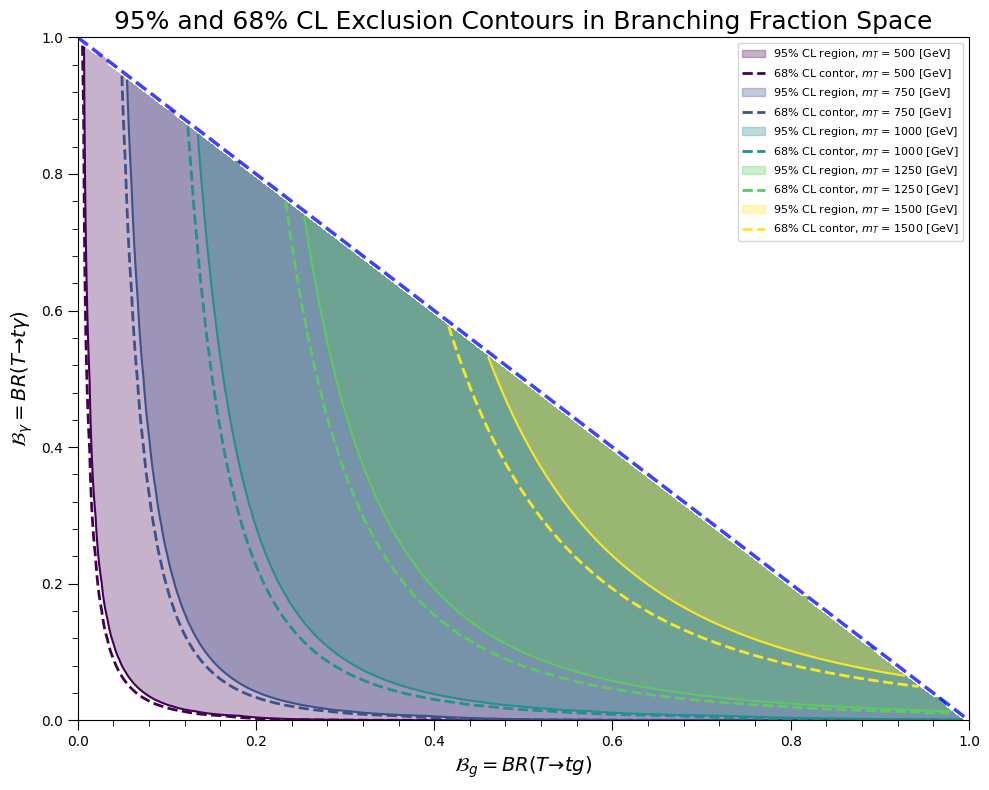

In [6]:
mass_points = [500, 750, 1000, 1250, 1500]#, 1750, 2000]
colors = plt.cm.viridis(np.linspace(0, 1, len(mass_points)))
plt.figure(figsize=(10, 8))
chi2_68 = chi2.ppf(0.68, df=11)
chi2_95 = chi2.ppf(0.95, df=11)
legend_handles = []

for i, mass in enumerate(mass_points): # 
    # compute_limit = ComputeLimit(mass)
    # compute_limit.find_contour(**dic[mass])
    compute_limit_br = ComputeLimitBR(mass)
    X, Y, Z = compute_limit_br.find_contour()
    plt.contourf(X, Y, Z, levels=[chi2_95, Z.max()], colors=[colors[i]], alpha=0.3)
    contour_95 = plt.contour(X, Y, Z, levels=[chi2_95], colors=[colors[i]], linewidths=1.5, linestyles='solid')
    contour_68 = plt.contour(X, Y, Z, levels=[chi2_68], colors=[colors[i]], linewidths=2, linestyles='dashed')
    
    patch = Patch(color=colors[i], alpha=0.3, label=f'95% CL region, $m_T$ = {mass} [GeV]')
    # line = Line2D([0], [0], color=colors[i], lw=1.5, linestyle='solid', label=f'95% CL contor, $m_T$ = {mass} [GeV]')
    line = Line2D([0], [0], color=colors[i], lw=2, linestyle='dashed', label=f'68% CL contor, $m_T$ = {mass} [GeV]')

    legend_handles.extend([patch, line])
            
x_line = np.linspace(0, 1, 100)
y_line = 1 - x_line
plt.plot(x_line, y_line, 'b--', lw=2.5, alpha=0.75, label='$\mathcal{B}_{\gamma} + \mathcal{B}_{g} \leq 1$')
    
    
ax = plt.gca() 
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_major_locator(MultipleLocator(0.2))

ax.xaxis.set_minor_locator(MultipleLocator(0.04))
ax.yaxis.set_minor_locator(MultipleLocator(0.04))

ax.tick_params(axis='both', which='minor', length=4)
ax.tick_params(axis='both', which='major', length=7)

plt.xlabel('$\mathcal{B}_{g} = BR(T \\to tg)$', fontsize = 14)
plt.ylabel('$\mathcal{B}_{\gamma} = BR(T \\to t\gamma)$', fontsize = 14)
plt.title(f'95% and 68% CL Exclusion Contours in Branching Fraction Space', fontsize = 18)
# plt.grid()
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.legend(handles=legend_elements)

# plt.savefig(f'plots/limit_br_{self.mass}.svg', format='svg', dpi=1200)
plt.legend(handles=legend_handles, ncol=1, loc='upper right', fontsize=8, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f"plots/limit_br.png")
plt.show()
    

KeyboardInterrupt: 

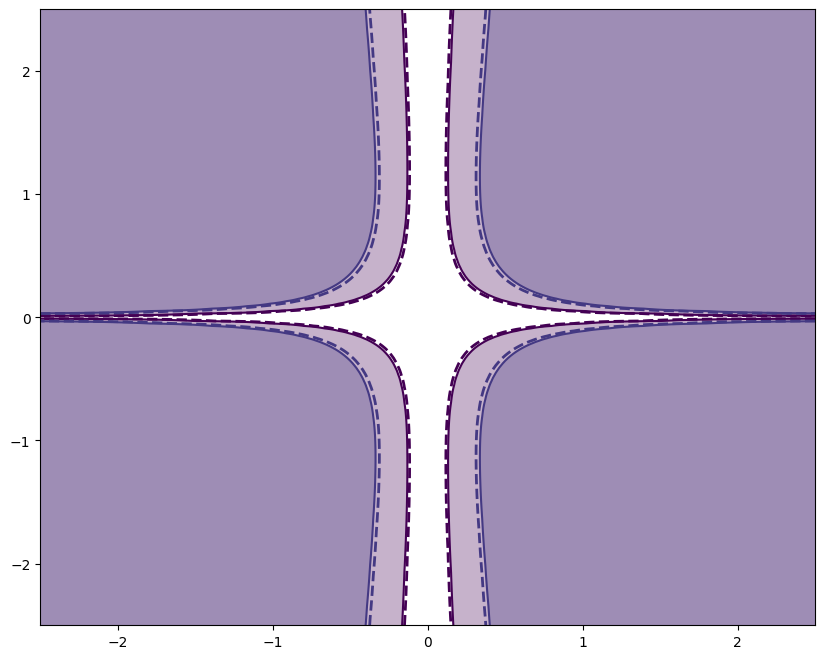

In [7]:
mass_points = [500, 750, 1000, 1250, 1500, 1750, 2000]
colors = plt.cm.viridis(np.linspace(0, 1, len(mass_points)))
plt.figure(figsize=(10, 8))
chi2_68 = chi2.ppf(0.68, df=11)
chi2_95 = chi2.ppf(0.95, df=11)
legend_handles = []

for i, mass in enumerate(mass_points): # 
    # compute_limit = ComputeLimit(mass)
    # compute_limit.find_contour(**dic[mass])
    compute_limit = ComputeLimit(mass)
    X, Y, Z = compute_limit.find_contour()
    plt.contourf(X, Y, Z, levels=[chi2_95, Z.max()], colors=[colors[i]], alpha=0.3)
    contour_95 = plt.contour(X, Y, Z, levels=[chi2_95], colors=[colors[i]], linewidths=1.5, linestyles='solid')
    contour_68 = plt.contour(X, Y, Z, levels=[chi2_68], colors=[colors[i]], linewidths=2, linestyles='dashed')
    
    patch = Patch(color=colors[i], alpha=0.3, label=f'95% CL region, $m_T$ = {mass} [GeV]')
    # line = Line2D([0], [0], color=colors[i], lw=1.5, linestyle='solid', label=f'95% CL contor, $m_T$ = {mass} [GeV]')
    line = Line2D([0], [0], color=colors[i], lw=2, linestyle='dashed', label=f'68% CL contor, $m_T$ = {mass} [GeV]')

    legend_handles.extend([patch, line])
    
# Horizontal line at y = 0
plt.axhline(0, color='black', linestyle='--', linewidth=1)
# Vertical line at x = 0
plt.axvline(0, color='black', linestyle='--', linewidth=1)
    
ax = plt.gca() 
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_major_locator(MultipleLocator(0.5))

ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))

ax.tick_params(axis='both', which='minor', length=4)
ax.tick_params(axis='both', which='major', length=7)

plt.xlabel('$g_{3g} (\mathrm{TeV^{-1}})$', fontsize = 14)
plt.ylabel('$g_{3\\gamma} (\mathrm{TeV^{-1}})$', fontsize = 14)
plt.title(f'95% and 68% CL Exclusion Contours in Coupling Space', fontsize = 18)
# plt.grid()
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.legend(handles=legend_elements)

# plt.savefig(f'plots/limit_br_{self.mass}.svg', format='svg', dpi=1200)
plt.legend(handles=legend_handles, ncol=1, loc='upper right', fontsize=8, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f"plots/limit_g.png")
plt.show()
    

In [ ]:
dic = {
    500: {"g3g_range": (-1, 1), "g3gamma_range": (-1, 1), "n_points": 100},
    750: {"g3g_range": (-1.5, 1.5), "g3gamma_range": (-1.5, 1.5), "n_points": 100},
    1000: {"g3g_range": (-2.5, 2.5), "g3gamma_range": (-2.5, 2.5), "n_points": 150},
    1250: {"g3g_range": (-3.5, 3.5), "g3gamma_range": (-3.5, 3.5), "n_points": 150},
    1500: {"g3g_range": (-4.5, 4.5), "g3gamma_range": (-4.5, 4.5), "n_points": 150},
    1750: {"g3g_range": (-5.5, 5.5), "g3gamma_range": (-5.5, 5.5), "n_points": 150},
    2000: {"g3g_range": (-6.5, 6.5), "g3gamma_range": (-6.5, 6.5), "n_points": 150},
}
for mass in [500, 750, 1000, 1250, 1500, 1750, 2000]: # 
    compute_limit = ComputeLimit(mass)
    compute_limit.find_contour(**dic[mass])
    compute_limit_br = ComputeLimitBR(mass)
    compute_limit_br.find_contour()